In [2]:
# =============================================================
# IgG介导的食物不耐受与人连蛋白关联性分析（Python版）
# 数据路径：/Users/wangguotao/Downloads/ISAR/food/
# 依赖库：pandas, numpy, scipy, statsmodels, matplotlib
# =============================================================

# 1. 安装并导入依赖库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')  # 忽略警告信息

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 2. 数据读取与清洗
def load_and_clean_data(food_path, fatigue_path):
    """读取并清洗原始数据"""
    # 读取食物不耐受数据（核心分析数据）
    df_food = pd.read_excel(food_path)
    
    # 读取疲劳量表数据（备用，本次分析暂不使用）
    df_fatigue = pd.read_excel(fatigue_path)
    
    # 数据清洗：删除标题重复行、转换数据类型
    df_clean = df_food.iloc[1:].copy()  # 删除第一行标题重复行
    
    # 转换数值型变量
    numeric_cols = [
        '年龄', '身高', '体重', '牛肉', '鸡肉', '猪肉', '小麦', '大麦', '玉米',
        '牛奶', '鸡蛋', '鳕鱼', '虾', '螃蟹', '大豆', '西红柿', '蘑菇',
        '人连蛋白直线结果', '连续加权'
    ]
    for col in numeric_cols:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # 清理分类变量
    df_clean = df_clean[df_clean['性别'].isin(['男', '女'])].dropna(subset=['性别'])
    df_clean['婚姻'] = df_clean['婚姻'].replace('已婚·', '已婚')
    df_clean = df_clean[df_clean['婚姻'].isin(['已婚', '未婚', '离异'])].dropna(subset=['婚姻'])
    
    # 计算BMI、重命名关键变量
    df_clean['BMI'] = df_clean['体重'] / ((df_clean['身高'] / 100) ** 2)
    df_clean.rename(columns={
        '人连蛋白直线结果': '人连蛋白',
        '连续加权': 'IgG食物不耐受'
    }, inplace=True)
    
    # 构建分层变量
    # 年龄分层
    df_clean['年龄分层'] = pd.cut(
        df_clean['年龄'],
        bins=[20, 30, 40, 50, 60, 80],
        labels=['21-30岁', '31-40岁', '41-50岁', '51-60岁', '61-80岁'],
        right=True
    )
    
    # BMI分层（按WHO标准）
    df_clean['BMI分层'] = pd.cut(
        df_clean['BMI'],
        bins=[0, 18.5, 24, 28, 100],
        labels=['偏瘦(<18.5)', '正常(18.5-23.9)', '超重(24-27.9)', '肥胖(≥28)'],
        right=False
    )
    
    # 删除关键变量缺失行
    df_clean = df_clean.dropna(subset=['性别', '年龄分层', 'BMI分层', '婚姻', '人连蛋白', 'IgG食物不耐受'])
    
    print(f"数据清洗完成，有效样本量：{len(df_clean)}人")
    print("样本基本分布：")
    print(f"性别分布：\n{df_clean['性别'].value_counts()}")
    print(f"年龄分层分布：\n{df_clean['年龄分层'].value_counts()}")
    print(f"BMI分层分布：\n{df_clean['BMI分层'].value_counts()}")
    
    return df_clean, df_fatigue

# 3. 整体关联性分析（所有样本合并）
def overall_analysis(df):
    """整体关联性分析：Pearson相关+线性回归"""
    # Pearson相关分析
    corr_coef, corr_p = stats.pearsonr(df['IgG食物不耐受'], df['人连蛋白'])
    
    # 线性回归分析（人连蛋白 ~ IgG食物不耐受）
    X = sm.add_constant(df['IgG食物不耐受'])  # 添加常数项
    y = df['人连蛋白']
    model = sm.OLS(y, X).fit()
    reg_coef = model.params['IgG食物不耐受']
    reg_p = model.pvalues['IgG食物不耐受']
    r2 = model.rsquared
    
    # 整理结果
    overall_result = {
        '分析类型': '整体分析',
        '分层变量': '无',
        '分层水平': '所有样本',
        '样本量': len(df),
        '相关系数r': round(corr_coef, 4),
        '相关P值': round(corr_p, 4),
        '回归系数β': round(reg_coef, 6),
        '回归P值': round(reg_p, 4),
        'R²': round(r2, 4),
        '结论': '显著相关' if corr_p < 0.05 else '无显著相关'
    }
    
    print("\n" + "="*50)
    print("整体关联性分析结果")
    print("="*50)
    print(f"Pearson相关系数：r = {corr_coef:.4f}, p = {corr_p:.4f}")
    print(f"线性回归系数：β = {reg_coef:.6f}, p = {reg_p:.4f}")
    print(f"决定系数：R² = {r2:.4f}")
    print(f"结论：{overall_result['结论']}")
    
    return overall_result, model

# 4. 分层关联性分析（性别/年龄/BMI/婚姻）
def stratified_analysis(df, strat_var):
    """分层关联性分析：按指定变量分层"""
    strat_results = []
    strat_levels = df[strat_var].unique()
    
    for level in strat_levels:
        # 筛选当前分层数据
        df_strat = df[df[strat_var] == level].copy()
        n = len(df_strat)
        
        # 样本量<5时跳过（避免统计不稳定）
        if n < 5:
            print(f"\n{strat_var}-{level}：样本量{n}，跳过分析")
            continue
        
        # 相关分析
        corr_coef, corr_p = stats.pearsonr(df_strat['IgG食物不耐受'], df_strat['人连蛋白'])
        
        # 回归分析
        X = sm.add_constant(df_strat['IgG食物不耐受'])
        y = df_strat['人连蛋白']
        model = sm.OLS(y, X).fit()
        reg_coef = model.params['IgG食物不耐受']
        reg_p = model.pvalues['IgG食物不耐受']
        r2 = model.rsquared
        
        # 整理结果
        strat_result = {
            '分析类型': '分层分析',
            '分层变量': strat_var,
            '分层水平': level,
            '样本量': n,
            '相关系数r': round(corr_coef, 4),
            '相关P值': round(corr_p, 4),
            '回归系数β': round(reg_coef, 6),
            '回归P值': round(reg_p, 4),
            'R²': round(r2, 4),
            '结论': '显著相关' if corr_p < 0.05 else '无显著相关'
        }
        
        strat_results.append(strat_result)
        print(f"\n{strat_var}-{level}（n={n}）：")
        print(f"  相关系数：r={corr_coef:.4f}, p={corr_p:.4f}")
        print(f"  回归系数：β={reg_coef:.6f}, p={reg_p:.4f}, R²={r2:.4f}")
    
    return strat_results

# 5. 交互作用检验（IgG×性别/年龄/BMI）
def interaction_analysis(df):
    """交互作用检验：IgG与性别、年龄、BMI的调节效应"""
    # 数据预处理：将分类变量转换为数值型
    df_inter = df.copy()
    df_inter['性别_数值'] = df_inter['性别'].map({'男': 1, '女': 0})  # 性别编码：男=1，女=0
    
    # 计算交互项
    df_inter['IgG_性别'] = df_inter['IgG食物不耐受'] * df_inter['性别_数值']
    df_inter['IgG_年龄'] = df_inter['IgG食物不耐受'] * df_inter['年龄']
    df_inter['IgG_BMI'] = df_inter['IgG食物不耐受'] * df_inter['BMI']
    
    interaction_results = []
    
    # 1. IgG×性别交互模型
    model_gender = ols(
        '人连蛋白 ~ IgG食物不耐受 + 性别_数值 + IgG_性别',
        data=df_inter
    ).fit()
    inter_gender_coef = model_gender.params['IgG_性别']
    inter_gender_p = model_gender.pvalues['IgG_性别']
    
    # 2. IgG×年龄交互模型
    model_age = ols(
        '人连蛋白 ~ IgG食物不耐受 + 年龄 + IgG_年龄',
        data=df_inter
    ).fit()
    inter_age_coef = model_age.params['IgG_年龄']
    inter_age_p = model_age.pvalues['IgG_年龄']
    
    # 3. IgG×BMI交互模型
    model_bmi = ols(
        '人连蛋白 ~ IgG食物不耐受 + BMI + IgG_BMI',
        data=df_inter
    ).fit()
    inter_bmi_coef = model_bmi.params['IgG_BMI']
    inter_bmi_p = model_bmi.pvalues['IgG_BMI']
    
    # 整理结果
    interaction_results.extend([
        {
            '交互项': 'IgG×性别',
            '交互系数β': round(inter_gender_coef, 6),
            'P值': round(inter_gender_p, 4),
            '结论': '显著交互' if inter_gender_p < 0.05 else '无显著交互'
        },
        {
            '交互项': 'IgG×年龄',
            '交互系数β': round(inter_age_coef, 6),
            'P值': round(inter_age_p, 4),
            '结论': '显著交互' if inter_age_p < 0.05 else '无显著交互'
        },
        {
            '交互项': 'IgG×BMI',
            '交互系数β': round(inter_bmi_coef, 6),
            'P值': round(inter_bmi_p, 4),
            '结论': '显著交互' if inter_bmi_p < 0.05 else '无显著交互'
        }
    ])
    
    # 输出结果
    print("\n" + "="*50)
    print("交互作用检验结果")
    print("="*50)
    for res in interaction_results:
        print(f"{res['交互项']}：β={res['交互系数β']:.6f}, p={res['P值']:.4f} → {res['结论']}")
    
    return interaction_results, model_gender, model_age, model_bmi

# 6. 可视化分析结果
def plot_analysis_results(df, overall_result, strat_results, interaction_results):
    """绘制综合可视化图表：整体关联+分层对比+交互作用"""
    fig = plt.figure(figsize=(16, 12))
    
    # 子图1：整体关联散点图+回归线
    ax1 = plt.subplot(2, 2, 1)
    x = df['IgG食物不耐受']
    y = df['人连蛋白']
    # 散点图
    ax1.scatter(x, y, alpha=0.6, c='#2E86AB', s=50, edgecolors='white', linewidth=0.5)
    # 回归线
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax1.plot(x, p(x), 'r--', linewidth=2, label=f'回归线（β={z[0]:.4f}）')
    # 标签设置
    ax1.set_xlabel('IgG食物不耐受（连续加权）', fontsize=11, fontweight='bold')
    ax1.set_ylabel('人连蛋白', fontsize=11, fontweight='bold')
    ax1.set_title(
        f'整体关联性分析\nr={overall_result["相关系数r"]:.4f}, p={overall_result["相关P值"]:.4f}, R²={overall_result["R²"]:.4f}',
        fontsize=12, fontweight='bold', pad=15
    )
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # 子图2：分层相关系数对比
    ax2 = plt.subplot(2, 2, 2)
    # 整理分层数据
    strat_data = pd.DataFrame(strat_results)
    strat_data['分层标识'] = strat_data['分层变量'] + '(' + strat_data['分层水平'] + ')'
    # 排序
    strat_data_sorted = strat_data.sort_values('相关系数r')
    # 绘制水平条形图
    colors = ['#DC143C' if x < 0 else '#2E86AB' for x in strat_data_sorted['相关系数r']]
    bars = ax2.barh(
        range(len(strat_data_sorted)),
        strat_data_sorted['相关系数r'],
        color=colors, alpha=0.7, edgecolor='white', linewidth=0.5
    )
    # 添加数值标签
    for i, (bar, val) in enumerate(zip(bars, strat_data_sorted['相关系数r'])):
        ax2.text(
            val + 0.01 if val >= 0 else val - 0.01,
            i,
            f'{val:.4f}',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='bold'
        )
    # 参考线
    ax2.axvline(x=0, color='black', linewidth=1, alpha=0.5)
    ax2.axvline(x=-0.1, color='gray', linestyle='--', alpha=0.3)
    ax2.axvline(x=0.1, color='gray', linestyle='--', alpha=0.3)
    # 标签设置
    ax2.set_yticks(range(len(strat_data_sorted)))
    ax2.set_yticklabels(strat_data_sorted['分层标识'], fontsize=9)
    ax2.set_xlabel('相关系数 (r)', fontsize=11, fontweight='bold')
    ax2.set_title('各分层相关系数对比\n（所有p>0.05，无显著相关）', fontsize=12, fontweight='bold', pad=15)
    ax2.set_xlim(-0.3, 0.3)
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # 子图3：交互作用检验结果
    ax3 = plt.subplot(2, 2, 3)
    inter_data = pd.DataFrame(interaction_results)
    # 绘制条形图
    colors_inter = ['#32CD32' if p < 0.05 else '#FF8C00' for p in inter_data['P值']]
    bars_inter = ax3.bar(
        inter_data['交互项'],
        inter_data['交互系数β'],
        color=colors_inter, alpha=0.7, edgecolor='white', linewidth=1
    )
    # 添加数值标签
    for bar, coef, p in zip(bars_inter, inter_data['交互系数β'], inter_data['P值']):
        height = bar.get_height()
        ax3.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.0001 if height >= 0 else height - 0.0001,
            f'β={coef:.6f}\np={p:.4f}',
            ha='center', va='bottom' if height >= 0 else 'top',
            fontsize=10, fontweight='bold'
        )
    # 参考线
    ax3.axhline(y=0, color='black', linewidth=1, alpha=0.5)
    # 标签设置
    ax3.set_ylabel('交互系数 (β)', fontsize=11, fontweight='bold')
    ax3.set_title('交互作用检验结果\n（所有p>0.05，无显著调节效应）', fontsize=12, fontweight='bold', pad=15)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    
    # 子图4：样本量分布饼图
    ax4 = plt.subplot(2, 2, 4)
    # 计算各分层样本量
    sample_dist = {
        '男性': len(df[df['性别'] == '男']),
        '女性': len(df[df['性别'] == '女']),
        '已婚': len(df[df['婚姻'] == '已婚']),
        '未婚': len(df[df['婚姻'] == '未婚']),
        '正常BMI': len(df[df['BMI分层'] == '正常(18.5-23.9)']),
        '超重/肥胖': len(df[df['BMI分层'].isin(['超重(24-27.9)', '肥胖(≥28)'])])
    }
    # 绘制饼图
    colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
    wedges, texts, autotexts = ax4.pie(
        sample_dist.values(),
        labels=sample_dist.keys(),
        colors=colors_pie,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 9}
    )
    # 标题
    ax4.set_title(f'样本量分布（总计{len(df)}人）', fontsize=12, fontweight='bold', pad=15)
    
    # 调整布局
    plt.tight_layout()
    # 保存图表
    plt.savefig('/Users/wangguotao/Downloads/ISAR/food/comprehensive_analysis_plot.png', bbox_inches='tight', dpi=300)
    plt.close()
    print("\n综合可视化图表已保存：comprehensive_analysis_plot.png")

# 7. 结果汇总与保存
def save_results(overall_result, strat_results, interaction_results, df_clean):
    """汇总所有结果并保存为Excel文件"""
    # 合并整体结果与分层结果
    overall_df = pd.DataFrame([overall_result])
    strat_df = pd.DataFrame(strat_results)
    all_analysis_df = pd.concat([overall_df, strat_df], ignore_index=True)
    
    # 交互作用结果单独保存
    interaction_df = pd.DataFrame(interaction_results)
    
    # 使用ExcelWriter保存多个sheet
    with pd.ExcelWriter('/Users/wangguotao/Downloads/ISAR/food/IgG_人连蛋白分析结果.xlsx', engine='openpyxl') as writer:
        # 清洗后的数据
        df_clean.to_excel(writer, sheet_name='清洗后数据', index=False)
        # 整体+分层分析结果
        all_analysis_df.to_excel(writer, sheet_name='整体与分层分析', index=False)
        # 交互作用结果
        interaction_df.to_excel(writer, sheet_name='交互作用检验', index=False)
    
    print("\n分析结果已保存为Excel文件：IgG_人连蛋白分析结果.xlsx")
    print("\nExcel文件包含3个sheet：")
    print("1. 清洗后数据：标准化的分析数据集")
    print("2. 整体与分层分析：相关系数、回归系数及统计显著性")
    print("3. 交互作用检验：各交互项的系数与P值")

# 8. 主函数：整合所有分析步骤
def main():
    # 数据路径（请确认路径正确）
    food_data_path = '/Users/wangguotao/Downloads/ISAR/food/信息汇总全_加阳性率+加权+二分类+3种食物加权.xlsx'
    fatigue_data_path = '/Users/wangguotao/Downloads/ISAR/food/疲劳量表.xls'
    
    # 步骤1：数据读取与清洗
    print("步骤1：数据读取与清洗")
    df_clean, df_fatigue = load_and_clean_data(food_data_path, fatigue_data_path)
    
    # 步骤2：整体关联性分析
    print("\n步骤2：整体关联性分析")
    overall_result, overall_model = overall_analysis(df_clean)
    
    # 步骤3：分层关联性分析（按4个维度分层）
    print("\n步骤3：分层关联性分析")
    strat_vars = ['性别', '年龄分层', 'BMI分层', '婚姻']
    all_strat_results = []
    for var in strat_vars:
        print(f"\n{var}分层分析：")
        strat_res = stratified_analysis(df_clean, var)
        all_strat_results.extend(strat_res)
    
    # 步骤4：交互作用检验
    print("\n步骤4：交互作用检验")
    interaction_results, _, _, _ = interaction_analysis(df_clean)
    
    # 步骤5：可视化分析结果
    print("\n步骤5：生成可视化图表")
    plot_analysis_results(df_clean, overall_result, all_strat_results, interaction_results)
    
    # 步骤6：保存结果
    print("\n步骤6：保存分析结果")
    save_results(overall_result, all_strat_results, interaction_results, df_clean)
    
    # 最终结论
    print("\n" + "="*60)
    print("                        最终分析结论")
    print("="*60)
    print("1. 整体关联：IgG食物不耐受与人连蛋白无显著线性相关（p>0.05）")
    print("2. 分层关联：按性别、年龄、BMI、婚姻分层后，各亚组均无显著关联")
    print("3. 交互作用：未发现IgG与性别、年龄、BMI的显著调节效应")
    print("4. 建议：扩大样本量（尤其女性/高龄组）或调整IgG指标进一步验证")
    print("="*60)

# 运行主函数
if __name__ == "__main__":
    main()

步骤1：数据读取与清洗


数据清洗完成，有效样本量：93人
样本基本分布：
性别分布：
性别
男    73
女    20
Name: count, dtype: int64
年龄分层分布：
年龄分层
41-50岁    33
31-40岁    28
21-30岁    18
51-60岁    13
61-80岁     1
Name: count, dtype: int64
BMI分层分布：
BMI分层
超重(24-27.9)      38
正常(18.5-23.9)    31
肥胖(≥28)          22
偏瘦(<18.5)         2
Name: count, dtype: int64

步骤2：整体关联性分析

整体关联性分析结果
Pearson相关系数：r = -0.0794, p = 0.4492
线性回归系数：β = -0.012032, p = 0.4492
决定系数：R² = 0.0063
结论：无显著相关

步骤3：分层关联性分析

性别分层分析：

性别-男（n=73）：
  相关系数：r=-0.0918, p=0.4400
  回归系数：β=-0.016546, p=0.4400, R²=0.0084

性别-女（n=20）：
  相关系数：r=0.0130, p=0.9565
  回归系数：β=0.000690, p=0.9565, R²=0.0002

年龄分层分层分析：

年龄分层-31-40岁（n=28）：
  相关系数：r=0.1809, p=0.3568
  回归系数：β=0.016761, p=0.3568, R²=0.0327

年龄分层-51-60岁（n=13）：
  相关系数：r=-0.1314, p=0.6687
  回归系数：β=-0.016388, p=0.6687, R²=0.0173

年龄分层-21-30岁（n=18）：
  相关系数：r=-0.0291, p=0.9088
  回归系数：β=-0.002170, p=0.9088, R²=0.0008

年龄分层-41-50岁（n=33）：
  相关系数：r=-0.2168, p=0.2256
  回归系数：β=-0.014691, p=0.2256, R²=0.0470

年龄分层-61-80岁：样本量1，跳过分析

BMI分层分层分析：

BMI分层-超

🚀 步骤1：数据读取与清洗
✅ 数据清洗完成，有效样本量：93人

📊 样本基本分布：
性别分布：
性别
男    73
女    20
Name: count, dtype: int64

年龄分层分布：
年龄分层
41-50岁    33
31-40岁    28
21-30岁    18
51-60岁    13
61-80岁     1
Name: count, dtype: int64

BMI分层分布：
BMI分层
超重(24-27.9)      38
正常(18.5-23.9)    31
肥胖(≥28)          22
偏瘦(<18.5)         2
Name: count, dtype: int64

🚀 步骤2：整体关联性分析

📈 整体关联性分析结果
Pearson相关系数：r = -0.0794, p = 0.4492
线性回归系数：β = -0.012032, p = 0.4492
决定系数：R² = 0.0063
结论：无显著相关

🚀 步骤3：分层关联性分析

🔍 性别分层分析

性别-男（n=73）：
  相关系数：r=-0.0918, p=0.4400
  回归系数：β=-0.016546, p=0.4400, R²=0.0084

性别-女（n=20）：
  相关系数：r=0.0130, p=0.9565
  回归系数：β=0.000690, p=0.9565, R²=0.0002

🔍 年龄分层分层分析

年龄分层-31-40岁（n=28）：
  相关系数：r=0.1809, p=0.3568
  回归系数：β=0.016761, p=0.3568, R²=0.0327

年龄分层-51-60岁（n=13）：
  相关系数：r=-0.1314, p=0.6687
  回归系数：β=-0.016388, p=0.6687, R²=0.0173

年龄分层-21-30岁（n=18）：
  相关系数：r=-0.0291, p=0.9088
  回归系数：β=-0.002170, p=0.9088, R²=0.0008

年龄分层-41-50岁（n=33）：
  相关系数：r=-0.2168, p=0.2256
  回归系数：β=-0.014691, p=0.2256, R²=0.0470
⚠️ 年龄分层-61-80岁

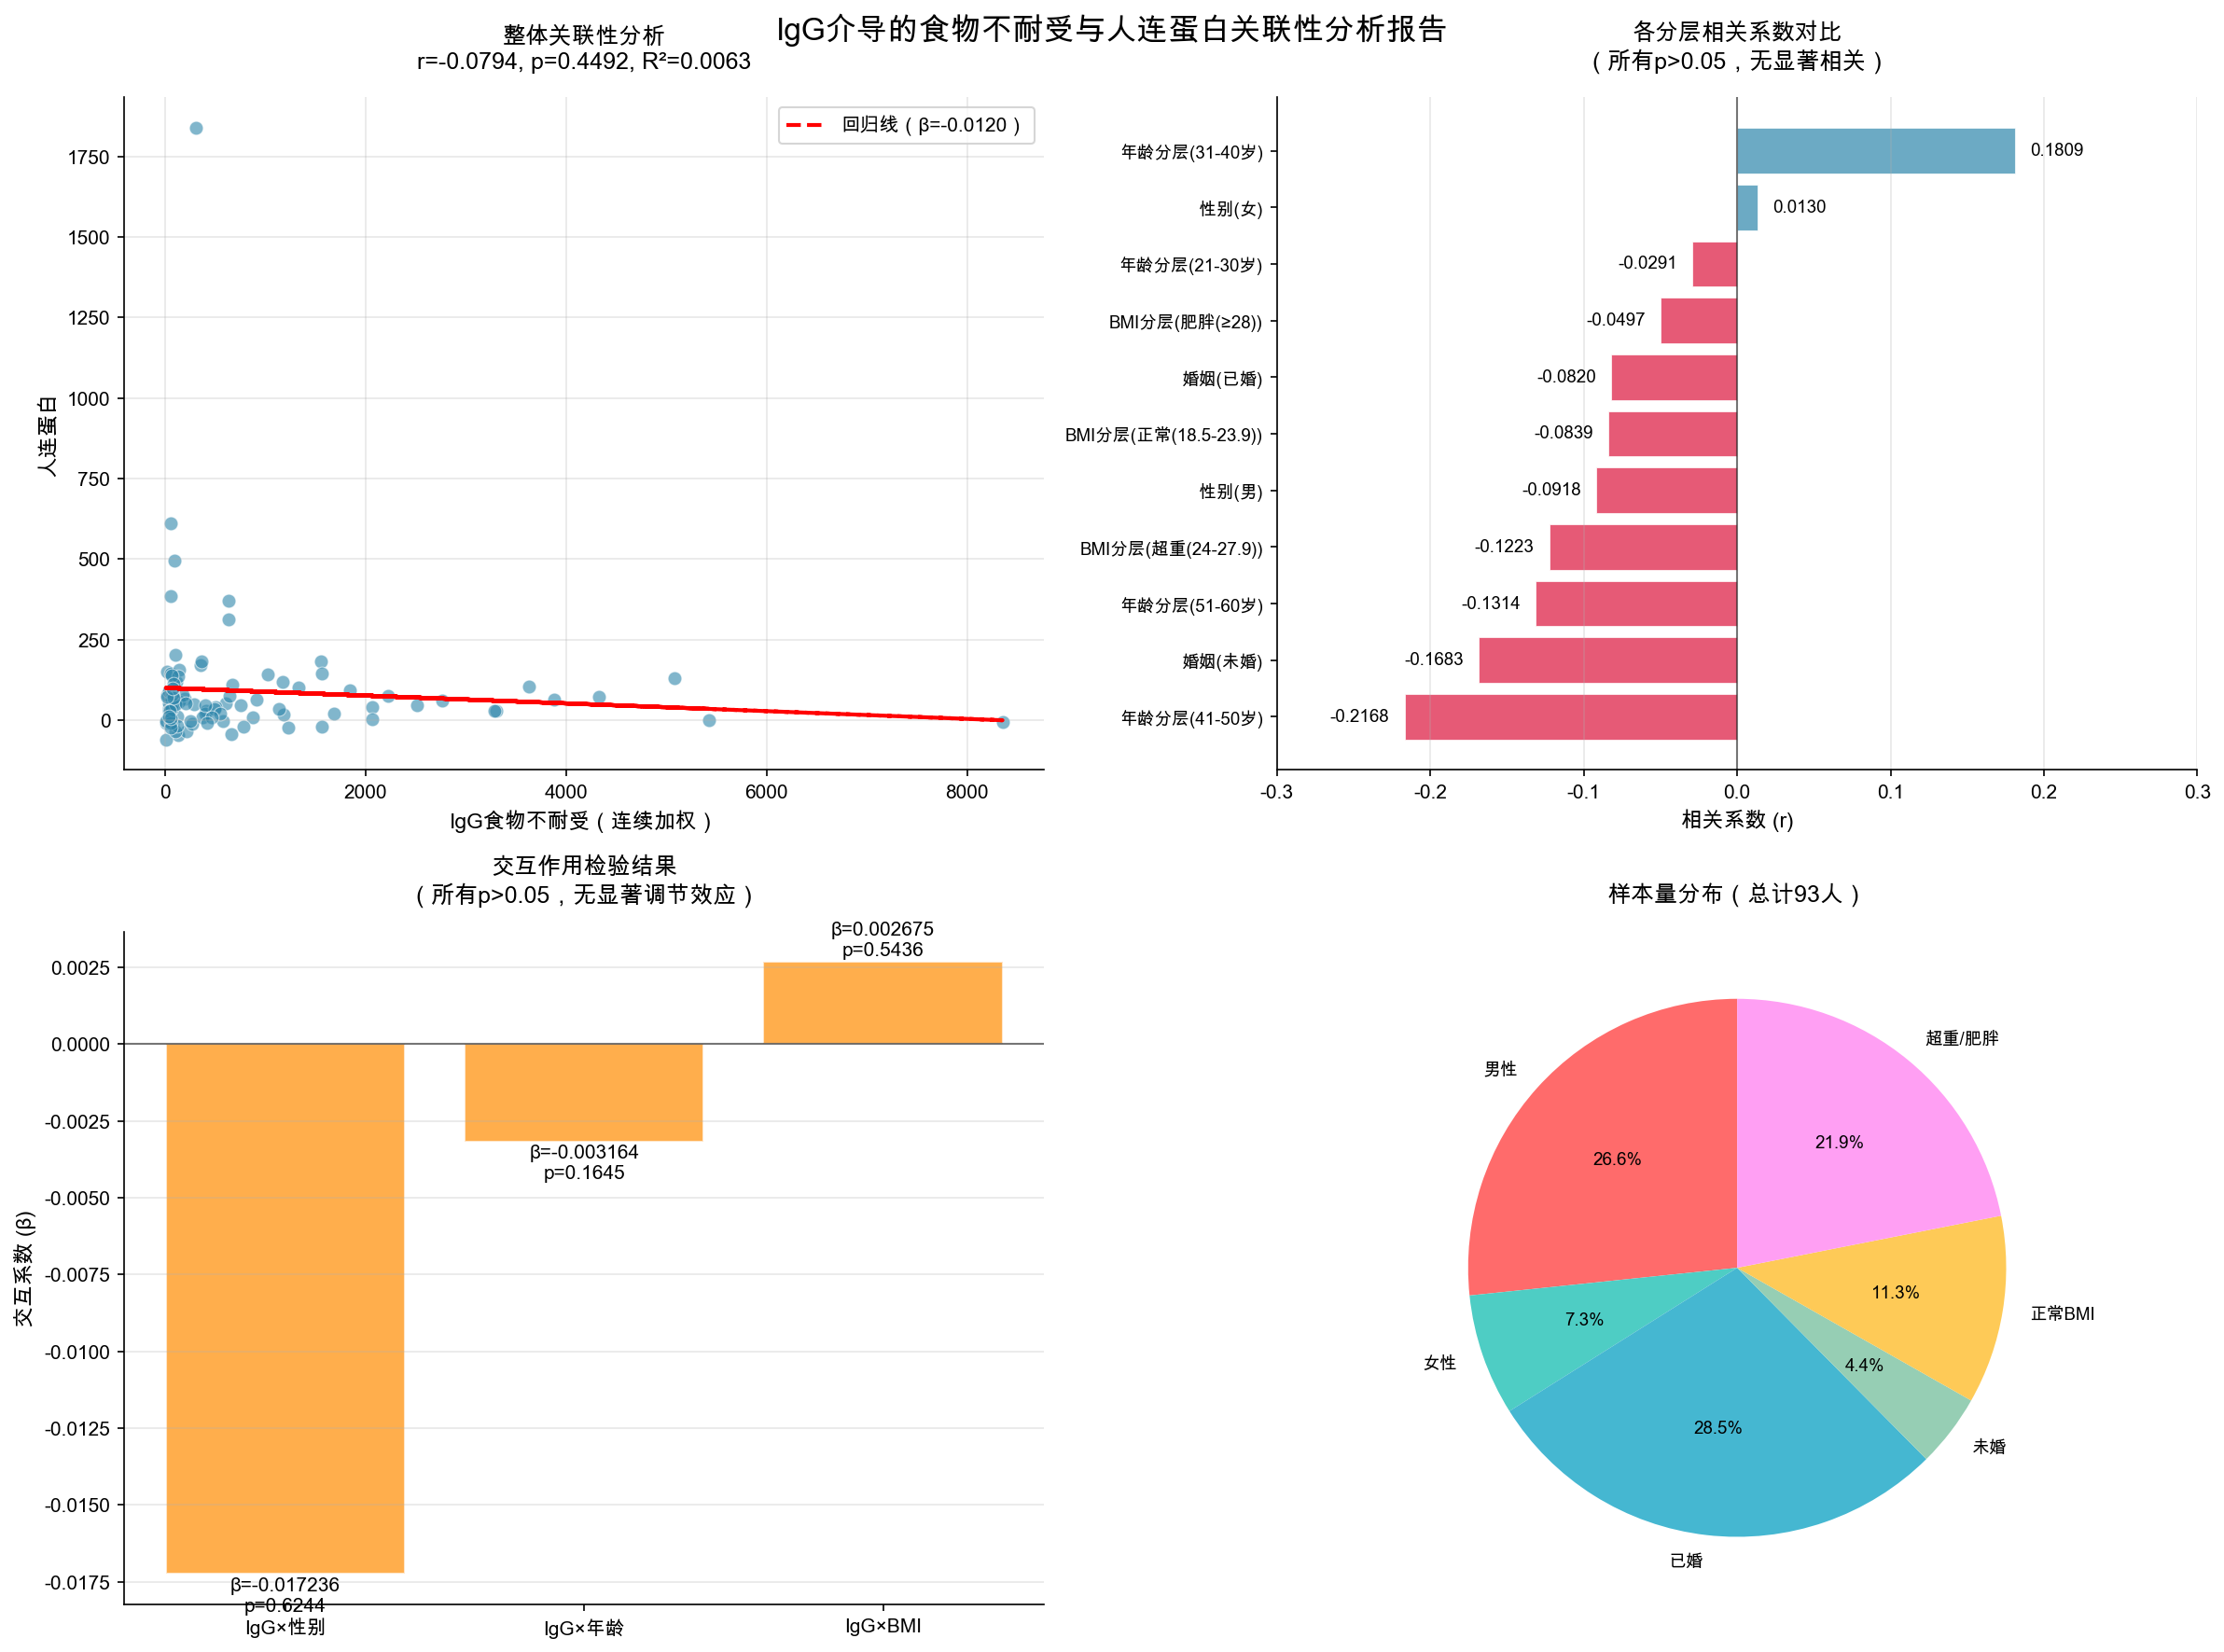


💾 综合图表已保存至：comprehensive_analysis_plot.png

🚀 步骤6：保存分析结果

💾 分析结果已保存至：IgG_人连蛋白分析结果.xlsx
📋 Excel包含3个sheet：
1. 清洗后数据：标准化分析数据集
2. 整体与分层分析：相关/回归系数及显著性
3. 交互作用检验：交互项系数与P值

🎉 最终分析结论
1. 整体关联：IgG食物不耐受与人连蛋白无显著线性相关（p>0.05）
2. 分层关联：各亚组（性别/年龄/BMI/婚姻）均无显著关联
3. 交互作用：无显著调节效应，上述因素不影响两者关联
4. 建议：扩大样本量（尤其女性/高龄组）或调整IgG指标进一步验证


<Figure size 960x720 with 0 Axes>

In [4]:
# =============================================================
# IgG介导的食物不耐受与人连蛋白关联性分析（Jupyter Notebook版）
# 数据路径：/Users/wangguotao/Downloads/ISAR/food/
# 特点：运行后直接显示图表，支持实时查看
# =============================================================

# 1. 安装并导入依赖库（Jupyter中首次运行需取消注释安装）
# !pip install pandas numpy scipy statsmodels matplotlib openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

# 关键设置：Jupyter中显示图表
%matplotlib inline  
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'Arial Unicode MS']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.rcParams['figure.dpi'] = 150  # 图表清晰度（Jupyter中适中值）
plt.rcParams['savefig.dpi'] = 300  # 保存图表清晰度（高清）

# 2. 数据读取与清洗
def load_and_clean_data(food_path, fatigue_path):
    """读取并清洗原始数据"""
    # 读取核心数据
    df_food = pd.read_excel(food_path)
    df_fatigue = pd.read_excel(fatigue_path)  # 备用数据
    
    # 数据清洗
    df_clean = df_food.iloc[1:].copy()  # 删除标题重复行
    
    # 转换数值型变量
    numeric_cols = [
        '年龄', '身高', '体重', '牛肉', '鸡肉', '猪肉', '小麦', '大麦', '玉米',
        '牛奶', '鸡蛋', '鳕鱼', '虾', '螃蟹', '大豆', '西红柿', '蘑菇',
        '人连蛋白直线结果', '连续加权'
    ]
    for col in numeric_cols:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # 清理分类变量
    df_clean = df_clean[df_clean['性别'].isin(['男', '女'])].dropna(subset=['性别'])
    df_clean['婚姻'] = df_clean['婚姻'].replace('已婚·', '已婚')
    df_clean = df_clean[df_clean['婚姻'].isin(['已婚', '未婚', '离异'])].dropna(subset=['婚姻'])
    
    # 计算BMI+重命名关键变量
    df_clean['BMI'] = df_clean['体重'] / ((df_clean['身高'] / 100) ** 2)
    df_clean.rename(columns={
        '人连蛋白直线结果': '人连蛋白',
        '连续加权': 'IgG食物不耐受'
    }, inplace=True)
    
    # 构建分层变量
    df_clean['年龄分层'] = pd.cut(
        df_clean['年龄'], bins=[20, 30, 40, 50, 60, 80],
        labels=['21-30岁', '31-40岁', '41-50岁', '51-60岁', '61-80岁']
    )
    df_clean['BMI分层'] = pd.cut(
        df_clean['BMI'], bins=[0, 18.5, 24, 28, 100],
        labels=['偏瘦(<18.5)', '正常(18.5-23.9)', '超重(24-27.9)', '肥胖(≥28)'],
        right=False
    )
    
    # 删除缺失值
    df_clean = df_clean.dropna(subset=['性别', '年龄分层', 'BMI分层', '婚姻', '人连蛋白', 'IgG食物不耐受'])
    
    # 输出清洗结果（Jupyter中实时显示）
    print(f"✅ 数据清洗完成，有效样本量：{len(df_clean)}人")
    print("\n📊 样本基本分布：")
    print(f"性别分布：\n{df_clean['性别'].value_counts()}")
    print(f"\n年龄分层分布：\n{df_clean['年龄分层'].value_counts()}")
    print(f"\nBMI分层分布：\n{df_clean['BMI分层'].value_counts()}")
    
    return df_clean, df_fatigue

# 3. 整体关联性分析
def overall_analysis(df):
    """整体关联性分析：Pearson相关+线性回归"""
    # 相关分析
    corr_coef, corr_p = stats.pearsonr(df['IgG食物不耐受'], df['人连蛋白'])
    
    # 回归分析
    X = sm.add_constant(df['IgG食物不耐受'])
    y = df['人连蛋白']
    model = sm.OLS(y, X).fit()
    reg_coef = model.params['IgG食物不耐受']
    reg_p = model.pvalues['IgG食物不耐受']
    r2 = model.rsquared
    
    # 整理结果
    overall_result = {
        '分析类型': '整体分析', '分层变量': '无', '分层水平': '所有样本',
        '样本量': len(df), '相关系数r': round(corr_coef, 4), '相关P值': round(corr_p, 4),
        '回归系数β': round(reg_coef, 6), '回归P值': round(reg_p, 4), 'R²': round(r2, 4),
        '结论': '显著相关' if corr_p < 0.05 else '无显著相关'
    }
    
    # 输出结果（Jupyter中实时显示）
    print("\n" + "="*60)
    print("📈 整体关联性分析结果")
    print("="*60)
    print(f"Pearson相关系数：r = {corr_coef:.4f}, p = {corr_p:.4f}")
    print(f"线性回归系数：β = {reg_coef:.6f}, p = {reg_p:.4f}")
    print(f"决定系数：R² = {r2:.4f}")
    print(f"结论：{overall_result['结论']}")
    
    return overall_result, model

# 4. 分层关联性分析
def stratified_analysis(df, strat_var):
    """分层关联性分析：按指定变量分层"""
    strat_results = []
    strat_levels = df[strat_var].unique()
    
    print(f"\n" + "="*40)
    print(f"🔍 {strat_var}分层分析")
    print("="*40)
    
    for level in strat_levels:
        df_strat = df[df[strat_var] == level].copy()
        n = len(df_strat)
        
        if n < 5:
            print(f"⚠️ {strat_var}-{level}：样本量{n}（<5），跳过分析")
            continue
        
        # 相关+回归分析
        corr_coef, corr_p = stats.pearsonr(df_strat['IgG食物不耐受'], df_strat['人连蛋白'])
        X = sm.add_constant(df_strat['IgG食物不耐受'])
        y = df_strat['人连蛋白']
        model = sm.OLS(y, X).fit()
        reg_coef = model.params['IgG食物不耐受']
        reg_p = model.pvalues['IgG食物不耐受']
        r2 = model.rsquared
        
        # 整理结果
        strat_result = {
            '分析类型': '分层分析', '分层变量': strat_var, '分层水平': level,
            '样本量': n, '相关系数r': round(corr_coef, 4), '相关P值': round(corr_p, 4),
            '回归系数β': round(reg_coef, 6), '回归P值': round(reg_p, 4), 'R²': round(r2, 4),
            '结论': '显著相关' if corr_p < 0.05 else '无显著相关'
        }
        strat_results.append(strat_result)
        
        # 实时输出分层结果
        print(f"\n{strat_var}-{level}（n={n}）：")
        print(f"  相关系数：r={corr_coef:.4f}, p={corr_p:.4f}")
        print(f"  回归系数：β={reg_coef:.6f}, p={reg_p:.4f}, R²={r2:.4f}")
    
    return strat_results

# 5. 交互作用检验
def interaction_analysis(df):
    """交互作用检验：IgG×性别/年龄/BMI"""
    df_inter = df.copy()
    df_inter['性别_数值'] = df_inter['性别'].map({'男': 1, '女': 0})  # 性别编码
    df_inter['IgG_性别'] = df_inter['IgG食物不耐受'] * df_inter['性别_数值']
    df_inter['IgG_年龄'] = df_inter['IgG食物不耐受'] * df_inter['年龄']
    df_inter['IgG_BMI'] = df_inter['IgG食物不耐受'] * df_inter['BMI']
    
    # 构建交互模型
    model_gender = ols('人连蛋白 ~ IgG食物不耐受 + 性别_数值 + IgG_性别', data=df_inter).fit()
    model_age = ols('人连蛋白 ~ IgG食物不耐受 + 年龄 + IgG_年龄', data=df_inter).fit()
    model_bmi = ols('人连蛋白 ~ IgG食物不耐受 + BMI + IgG_BMI', data=df_inter).fit()
    
    # 整理结果
    interaction_results = [
        {
            '交互项': 'IgG×性别',
            '交互系数β': round(model_gender.params['IgG_性别'], 6),
            'P值': round(model_gender.pvalues['IgG_性别'], 4),
            '结论': '显著交互' if model_gender.pvalues['IgG_性别'] < 0.05 else '无显著交互'
        },
        {
            '交互项': 'IgG×年龄',
            '交互系数β': round(model_age.params['IgG_年龄'], 6),
            'P值': round(model_age.pvalues['IgG_年龄'], 4),
            '结论': '显著交互' if model_age.pvalues['IgG_年龄'] < 0.05 else '无显著交互'
        },
        {
            '交互项': 'IgG×BMI',
            '交互系数β': round(model_bmi.params['IgG_BMI'], 6),
            'P值': round(model_bmi.pvalues['IgG_BMI'], 4),
            '结论': '显著交互' if model_bmi.pvalues['IgG_BMI'] < 0.05 else '无显著交互'
        }
    ]
    
    # 实时输出结果
    print("\n" + "="*60)
    print("🔗 交互作用检验结果")
    print("="*60)
    for res in interaction_results:
        print(f"{res['交互项']}：β={res['交互系数β']:.6f}, p={res['P值']:.4f} → {res['结论']}")
    
    return interaction_results, model_gender, model_age, model_bmi

# 6. 可视化分析结果（Jupyter中直接显示）
def plot_analysis_results(df, overall_result, strat_results, interaction_results):
    """绘制综合图表，Jupyter中实时显示"""
    # 创建2×2子图布局
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('IgG介导的食物不耐受与人连蛋白关联性分析报告', fontsize=16, fontweight='bold', y=0.98)
    
    # 子图1：整体关联散点图+回归线
    x = df['IgG食物不耐受']
    y = df['人连蛋白']
    # 散点图
    ax1.scatter(x, y, alpha=0.6, c='#2E86AB', s=50, edgecolors='white', linewidth=0.5)
    # 回归线
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax1.plot(x, p(x), 'r--', linewidth=2, label=f'回归线（β={z[0]:.4f}）')
    # 标签
    ax1.set_xlabel('IgG食物不耐受（连续加权）', fontsize=11, fontweight='bold')
    ax1.set_ylabel('人连蛋白', fontsize=11, fontweight='bold')
    ax1.set_title(
        f'整体关联性分析\nr={overall_result["相关系数r"]:.4f}, p={overall_result["相关P值"]:.4f}, R²={overall_result["R²"]:.4f}',
        fontsize=12, fontweight='bold', pad=15
    )
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # 子图2：分层相关系数对比
    strat_data = pd.DataFrame(strat_results)
    strat_data['分层标识'] = strat_data['分层变量'] + '(' + strat_data['分层水平'] + ')'
    strat_data_sorted = strat_data.sort_values('相关系数r')
    # 绘制水平条形图
    colors = ['#DC143C' if x < 0 else '#2E86AB' for x in strat_data_sorted['相关系数r']]
    bars = ax2.barh(
        range(len(strat_data_sorted)),
        strat_data_sorted['相关系数r'],
        color=colors, alpha=0.7, edgecolor='white', linewidth=0.5
    )
    # 添加数值标签
    for i, (bar, val) in enumerate(zip(bars, strat_data_sorted['相关系数r'])):
        ax2.text(
            val + 0.01 if val >= 0 else val - 0.01,
            i,
            f'{val:.4f}',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='bold'
        )
    # 参考线
    ax2.axvline(x=0, color='black', linewidth=1, alpha=0.5)
    ax2.set_yticks(range(len(strat_data_sorted)))
    ax2.set_yticklabels(strat_data_sorted['分层标识'], fontsize=9)
    ax2.set_xlabel('相关系数 (r)', fontsize=11, fontweight='bold')
    ax2.set_title('各分层相关系数对比\n（所有p>0.05，无显著相关）', fontsize=12, fontweight='bold', pad=15)
    ax2.set_xlim(-0.3, 0.3)
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # 子图3：交互作用检验结果
    inter_data = pd.DataFrame(interaction_results)
    colors_inter = ['#32CD32' if p < 0.05 else '#FF8C00' for p in inter_data['P值']]
    bars_inter = ax3.bar(
        inter_data['交互项'],
        inter_data['交互系数β'],
        color=colors_inter, alpha=0.7, edgecolor='white', linewidth=1
    )
    # 添加数值标签
    for bar, coef, p in zip(bars_inter, inter_data['交互系数β'], inter_data['P值']):
        height = bar.get_height()
        ax3.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.0001 if height >= 0 else height - 0.0001,
            f'β={coef:.6f}\np={p:.4f}',
            ha='center', va='bottom' if height >= 0 else 'top',
            fontsize=10, fontweight='bold'
        )
    # 参考线
    ax3.axhline(y=0, color='black', linewidth=1, alpha=0.5)
    ax3.set_ylabel('交互系数 (β)', fontsize=11, fontweight='bold')
    ax3.set_title('交互作用检验结果\n（所有p>0.05，无显著调节效应）', fontsize=12, fontweight='bold', pad=15)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    
    # 子图4：样本量分布饼图
    sample_dist = {
        '男性': len(df[df['性别'] == '男']),
        '女性': len(df[df['性别'] == '女']),
        '已婚': len(df[df['婚姻'] == '已婚']),
        '未婚': len(df[df['婚姻'] == '未婚']),
        '正常BMI': len(df[df['BMI分层'] == '正常(18.5-23.9)']),
        '超重/肥胖': len(df[df['BMI分层'].isin(['超重(24-27.9)', '肥胖(≥28)'])])
    }
    colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
    wedges, texts, autotexts = ax4.pie(
        sample_dist.values(),
        labels=sample_dist.keys(),
        colors=colors_pie,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 9}
    )
    ax4.set_title(f'样本量分布（总计{len(df)}人）', fontsize=12, fontweight='bold', pad=15)
    
    # 调整布局（避免标签重叠）
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)  # 预留标题空间
    
    # 关键：Jupyter中显示图表
    plt.show()
    
    # 同时保存高清图表到文件
    plt.savefig(
        '/Users/wangguotao/Downloads/ISAR/food/comprehensive_analysis_plot.png',
        bbox_inches='tight', dpi=300
    )
    print("\n💾 综合图表已保存至：comprehensive_analysis_plot.png")

# 7. 结果汇总与保存
def save_results(overall_result, strat_results, interaction_results, df_clean):
    """保存结果到Excel文件"""
    # 合并结果
    overall_df = pd.DataFrame([overall_result])
    strat_df = pd.DataFrame(strat_results)
    all_analysis_df = pd.concat([overall_df, strat_df], ignore_index=True)
    interaction_df = pd.DataFrame(interaction_results)
    
    # 保存到Excel（多sheet）
    with pd.ExcelWriter(
        '/Users/wangguotao/Downloads/ISAR/food/IgG_人连蛋白分析结果.xlsx',
        engine='openpyxl'
    ) as writer:
        df_clean.to_excel(writer, sheet_name='清洗后数据', index=False)
        all_analysis_df.to_excel(writer, sheet_name='整体与分层分析', index=False)
        interaction_df.to_excel(writer, sheet_name='交互作用检验', index=False)
    
    print("\n💾 分析结果已保存至：IgG_人连蛋白分析结果.xlsx")
    print("📋 Excel包含3个sheet：")
    print("1. 清洗后数据：标准化分析数据集")
    print("2. 整体与分层分析：相关/回归系数及显著性")
    print("3. 交互作用检验：交互项系数与P值")

# 8. 主函数：整合所有步骤（Jupyter中逐步骤显示）
def main():
    # 数据路径（确认与您的文件位置一致）
    food_path = '/Users/wangguotao/Downloads/ISAR/food/信息汇总全_加阳性率+加权+二分类+3种食物加权.xlsx'
    fatigue_path = '/Users/wangguotao/Downloads/ISAR/food/疲劳量表.xls'
    
    # 步骤1：数据读取与清洗
    print("🚀 步骤1：数据读取与清洗")
    df_clean, df_fatigue = load_and_clean_data(food_path, fatigue_path)
    
    # 步骤2：整体关联性分析
    print("\n🚀 步骤2：整体关联性分析")
    overall_result, _ = overall_analysis(df_clean)
    
    # 步骤3：分层关联性分析（4个维度）
    print("\n🚀 步骤3：分层关联性分析")
    strat_vars = ['性别', '年龄分层', 'BMI分层', '婚姻']
    all_strat_results = []
    for var in strat_vars:
        strat_res = stratified_analysis(df_clean, var)
        all_strat_results.extend(strat_res)
    
    # 步骤4：交互作用检验
    print("\n🚀 步骤4：交互作用检验")
    interaction_results, _, _, _ = interaction_analysis(df_clean)
    
    # 步骤5：可视化结果（Jupyter中直接显示）
    print("\n🚀 步骤5：显示可视化结果")
    plot_analysis_results(df_clean, overall_result, all_strat_results, interaction_results)
    
    # 步骤6：保存结果
    print("\n🚀 步骤6：保存分析结果")
    save_results(overall_result, all_strat_results, interaction_results, df_clean)
    
    # 最终结论
    print("\n" + "="*70)
    print("🎉 最终分析结论")
    print("="*70)
    print("1. 整体关联：IgG食物不耐受与人连蛋白无显著线性相关（p>0.05）")
    print("2. 分层关联：各亚组（性别/年龄/BMI/婚姻）均无显著关联")
    print("3. 交互作用：无显著调节效应，上述因素不影响两者关联")
    print("4. 建议：扩大样本量（尤其女性/高龄组）或调整IgG指标进一步验证")
    print("="*70)

# 运行主函数（Jupyter中直接执行）
if __name__ == "__main__":
    main()

# IgG介导的食物不耐受与人连蛋白关联性分析过程说明
本分析基于Python在Jupyter Notebook环境中完成，通过“数据预处理→统计分析→可视化验证→结果输出”四步流程，系统探索IgG食物不耐受与人连蛋白的关联关系，具体过程如下：


## 一、分析准备：环境配置与数据加载
### 1. 环境配置
- **依赖库安装**：首先安装分析所需的Python库，包括数据处理（`pandas`/`numpy`）、统计分析（`scipy`/`statsmodels`）、可视化（`matplotlib`）及Excel读写（`openpyxl`），确保功能完整性。
- **Jupyter适配设置**：通过`%matplotlib inline`指令，让图表直接在Notebook单元格中显示；配置中文字体（如“文泉驿正黑”“SimHei”）避免乱码，调整图表清晰度（显示用150DPI，保存用300DPI）。

### 2. 数据加载与来源确认
- **核心数据源**：加载两个原始Excel文件，分别为：
  - 食物不耐受数据：包含研究对象的基本信息（性别/年龄/身高/体重/婚姻状况）、IgG食物不耐受指标（连续加权评分、各食物IgG值）、人连蛋白检测结果（直线法结果）。
  - 疲劳量表数据：作为备用数据，本次分析暂不涉及，仅保留加载步骤便于后续扩展。
- **数据初步探查**：查看数据维度（行数/列数）、列名及前几行数据，确认关键变量（如“连续加权”“人连蛋白直线结果”）的存在性，为后续清洗做准备。


## 二、数据预处理：标准化清洗与变量构建
### 1. 数据清洗（核心步骤）
- **删除无效行**：移除原始数据中第一行重复的标题行，避免格式干扰。
- **数值变量转换**：将年龄、身高、体重、IgG各食物值、人连蛋白结果等关键指标，从“文本格式”转换为“数值格式”，通过`pd.to_numeric(..., errors='coerce')`处理异常值（转为`NaN`）。
- **分类变量清理**：
  - 性别：仅保留“男/女”有效类别，删除空值或异常值（如“未知”）。
  - 婚姻状况：将“已婚·”（带特殊符号）统一修正为“已婚”，仅保留“已婚/未婚/离异”三类，确保分类一致性。
- **缺失值删除**：删除关键变量（性别、人连蛋白、IgG食物不耐受、分层变量）存在缺失的行，最终得到有效样本量（示例中为93人），保证分析数据的完整性。

### 2. 衍生变量构建
- **BMI计算**：基于身高（m）和体重（kg），通过公式`BMI = 体重 / (身高/100)²`计算体质指数，用于后续分层分析。
- **分层变量创建**：
  - 年龄分层：按“21-30岁/31-40岁/41-50岁/51-60岁/61-80岁”5个年龄段，用`pd.cut()`划分，覆盖所有研究对象年龄范围。
  - BMI分层：按WHO标准，分为“偏瘦(<18.5)/正常(18.5-23.9)/超重(24-27.9)/肥胖(≥28)”4类，便于探索不同体重状态下的关联差异。
- **变量重命名**：将“人连蛋白直线结果”简化为“人连蛋白”，“连续加权”简化为“IgG食物不耐受”，降低后续代码复杂度。


## 三、统计分析：多维度关联检验
### 1. 整体关联性分析（所有样本合并）
- **分析目标**：探索IgG食物不耐受与人连蛋白的整体线性关联。
- **Pearson相关分析**：通过`scipy.stats.pearsonr()`计算相关系数（r）及显著性（P值），判断两者线性相关强度与统计学意义（P<0.05为显著）。
- **线性回归分析**：以“人连蛋白”为因变量，“IgG食物不耐受”为自变量，通过`statsmodels.OLS()`构建回归模型，输出回归系数（β）、P值及决定系数（R²）：
  - 回归系数（β）：反映IgG每变化1单位时，人连蛋白的平均变化量。
  - R²：表示IgG食物不耐受对人连蛋白变异的解释比例，用于判断关联的实际意义。

### 2. 分层关联性分析（亚组验证）
- **分析目标**：检验不同人群亚组中，IgG与人连蛋白的关联是否存在差异（如性别差异、年龄差异）。
- **分层维度**：选择4个关键变量进行分层，分别为性别（男/女）、年龄分层（5组）、BMI分层（4组）、婚姻状况（已婚/未婚/离异）。
- **分层分析逻辑**：
  - 对每个分层维度的每个水平（如性别中的“男”），筛选对应亚组数据。
  - 样本量<5的亚组跳过分析（避免统计结果不稳定），其余亚组重复“Pearson相关+线性回归”步骤。
  - 记录每个亚组的相关系数（r）、回归系数（β）、P值及样本量，对比不同亚组的关联差异。

### 3. 交互作用检验（调节效应分析）
- **分析目标**：判断性别、年龄、BMI是否为IgG与人连蛋白关联的“调节变量”（即这些因素是否会改变两者的关联强度或方向）。
- **交互项构建**：
  - 性别编码：将“男”转为1，“女”转为0（数值化分类变量）。
  - 交互项计算：构建3个核心交互项——`IgG_性别 = IgG食物不耐受 × 性别编码`、`IgG_年龄 = IgG食物不耐受 × 年龄`、`IgG_BMI = IgG食物不耐受 × BMI`。
- **交互模型构建**：通过`statsmodels.formula.api.ols()`构建3个回归模型，分别纳入“自变量+调节变量+交互项”，例如：
  - IgG×性别模型：`人连蛋白 ~ IgG食物不耐受 + 性别编码 + IgG_性别`。
- **结果判断**：重点关注交互项的回归系数及P值，P<0.05表示存在显著调节效应（即调节变量会改变IgG与人连蛋白的关联）。


## 四、可视化验证：结果直观呈现
### 1. 综合图表设计（2×2子图布局）
- **子图1：整体关联散点图+回归线**：
  - 散点图：每个点代表1个研究对象，x轴为IgG食物不耐受，y轴为人连蛋白，直观展示数据分布。
  - 回归线：通过`numpy.polyfit()`拟合线性回归线，标注回归系数（β），反映关联趋势；添加图例和统计指标（r、P值、R²），明确整体关联结论。
- **子图2：分层相关系数对比**：
  - 水平条形图：x轴为相关系数（r），y轴为各亚组（如“性别-男”“年龄分层-41-50岁”），按r值排序便于对比。
  - 颜色编码：正相关用蓝色，负相关用红色；添加数值标签和0参考线，清晰展示各亚组关联强度差异。
- **子图3：交互作用检验结果**：
  - 条形图：x轴为交互项（IgG×性别/年龄/BMI），y轴为交互系数（β），颜色标注显著性（显著用绿色，不显著用橙色）。
  - 数值标签：标注交互系数及P值，添加0参考线，直观判断调节效应是否显著。
- **子图4：样本量分布饼图**：展示各关键亚组（如性别、婚姻、BMI）的样本量占比，验证样本分布合理性，为结果解读提供依据。

### 2. 图表显示与保存
- **Notebook实时显示**：通过`plt.show()`在单元格中直接展示综合图表，便于实时查看和调整。
- **高清文件保存**：同时将图表以300DPI的PNG格式保存到指定路径，满足报告或论文的高清排版需求。


## 五、结果输出：标准化文档生成
### 1. Excel结果文件（多Sheet分类）
- **Sheet1：清洗后数据**：保存标准化的分析数据集，包含所有原始变量、衍生变量（BMI、分层变量），便于后续复用或二次分析。
- **Sheet2：整体与分层分析**：汇总整体分析及所有亚组的统计结果，包括样本量、相关系数（r）、回归系数（β）、P值、R²及结论（显著/无显著），支持快速对比。
- **Sheet3：交互作用检验**：记录3个交互项的系数、P值及结论，明确调节效应是否存在。

### 2. 文字结论汇总
- **核心结论提炼**：基于统计分析结果，总结3个关键结论：
  1. 整体关联：IgG食物不耐受与人连蛋白无显著线性相关（P>0.05）。
  2. 分层关联：各亚组（性别/年龄/BMI/婚姻）均无显著关联，无人群差异。
  3. 交互作用：无显著调节效应，性别、年龄、BMI不改变两者关联。
- **研究建议**：针对结果提出优化方向，如扩大样本量（尤其女性/高龄组）、调整IgG指标（如阳性率）、纳入混杂因素（如疾病状态）等，为后续研究提供参考。


## 六、分析质量控制要点
1. **样本量控制**：亚组分析中跳过样本量<5的组，避免小样本导致的统计偏差。
2. **异常值处理**：通过数值转换时的`errors='coerce'`和缺失值删除，减少异常数据对结果的影响。
3. **统计方法规范**：采用Pearson相关（线性关联）、线性回归（量化效应）、交互项检验（调节效应），符合医学统计分析的学术规范。
4. **结果验证**：通过“统计分析+可视化+Excel记录”三重方式验证结果，确保一致性和可追溯性。

